In [1]:
import numpy as np
import matplotlib.pyplot as plt
import kerrgeodesics as kg

In [2]:
# set orbit
a = 0.5
p = 7.0
e = 0.7
x = 0.5
err = 1E-15

In [3]:
# compute orbital parameters
orbital_parameters = kg.korb_params()
eccentric = 1
inclined = 1
kg.korb_getparams(eccentric, inclined, a, p, e, x, err, orbital_parameters);

In [4]:
# loop over one radial period and compute trajectory

Mino_radial_period = orbital_parameters.Vr
delta_lambda = 0.01
lam = 0.0
lambdas = np.arange(0.0, Mino_radial_period, delta_lambda)
trajectory_data = []

for lam in lambdas:
    psi = kg.korb_psifromla(lam, orbital_parameters)
    trajectory_data.append([
        kg.korb_tfromla(lam, orbital_parameters),
        kg.korb_rfrompsi(psi, orbital_parameters),
        kg.korb_thfromla(lam, orbital_parameters),
        kg.korb_phifromla(lam, orbital_parameters),
        kg.korb_getfourvel_equatorial(psi, orbital_parameters)
    ])

t, r_p, theta_p, phi_p, u_r = np.array(trajectory_data).T

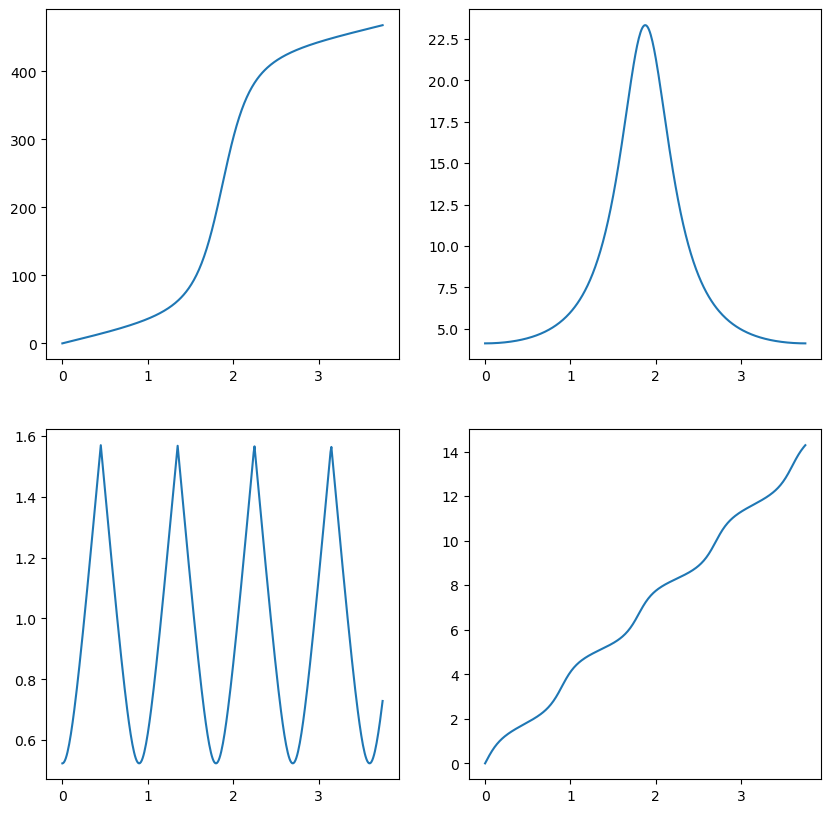

In [5]:
fig, axs = plt.subplots(ncols=2, nrows=2, figsize=(10,10))
for coord, ax in zip([t, r_p, theta_p, phi_p], axs.ravel()):
    ax.plot(lambdas, coord)

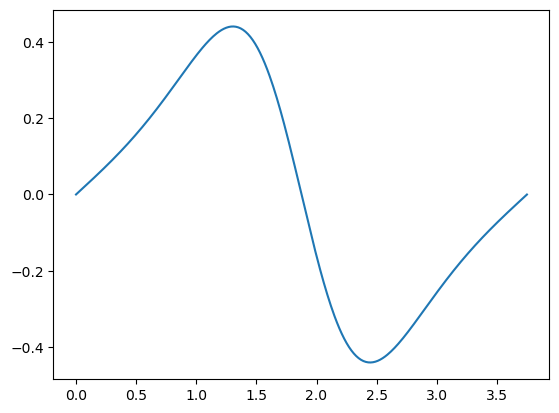

In [7]:
plt.plot(lambdas, u_r)
plt.show()